# 02 · Uncertainty quantification

Three methods, side by side:

* **Linear propagation** — closed-form, computed from leaf statistics saved at fit time.
* **Quadratic difference** — refits each leaf with quadratic features and reports `|linear - quadratic|`.
* **Mondrian leaf conformal** — distribution-free intervals with finite-sample coverage, calibrated on a held-out set.


In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jax_ldt import (
    LinearTreeRegressor,
    LinearPropagationUQ,
    QuadraticUQ,
    ConformalCalibrator,
)


## Train + calibration split on a noisy 1D toy

In [2]:
rng = np.random.default_rng(42)
# Use a larger N so the empirical-coverage estimate has lower variance.
# The conformal guarantee is *marginal*; finite-sample fluctuations are
# ~sqrt(alpha*(1-alpha)/N_test), which is roughly +/-1.5 pts at N_test=1500.
N = 4000
X = rng.uniform(-3, 3, size=(N, 1))
noise = 0.1 + 0.3 * (X[:, 0] > 0)  # heteroscedastic
y = np.sin(X[:, 0]) + noise * rng.standard_normal(N)

# 60/20/20 train/cal/test
perm = rng.permutation(N)
tr, cal, te = np.split(perm, [int(0.6 * N), int(0.8 * N)])
X_tr, y_tr = X[tr], y[tr]
X_cal, y_cal = X[cal], y[cal]
X_te, y_te = X[te], y[te]

# 1D: hyperplanes don't add anything, so use the axis-aligned tree.
model = LinearTreeRegressor(
    max_depth=5, max_bins=8, min_samples_leaf=20,
).fit(X_tr, y_tr)

print(f"train MAE: {float(jnp.mean(jnp.abs(model.predict(X_tr) - y_tr))):.3f}")
print(f"test  MAE: {float(jnp.mean(jnp.abs(model.predict(X_te) - y_te))):.3f}")


train MAE: 0.195


test  MAE: 0.195


## Linear-propagation and quadratic UQ

In [3]:
sigma_lp = np.asarray(LinearPropagationUQ().predict(model.tree_, X_te))
quq = QuadraticUQ(ridge=1e-5).calibrate(model.tree_, X_tr, y_tr)
sigma_q = np.asarray(quq.predict(model.tree_, X_te))

print(f"linprop sigma  mean={sigma_lp.mean():.3f}  median={np.median(sigma_lp):.3f}")
print(f"quadratic dev mean={sigma_q.mean():.3f}  median={np.median(sigma_q):.3f}")


linprop sigma  mean=0.091  median=0.079
quadratic dev mean=0.008  median=0.005


## Mondrian leaf conformal

In [4]:
calib = ConformalCalibrator(
    alpha=0.1, mondrian=True, min_calibration_per_leaf=5,
).calibrate(model, X_cal, y_cal)
lo, hi = calib.predict_interval(X_te, model=model)
lo = np.asarray(lo); hi = np.asarray(hi)

coverage = float(np.mean((y_te >= lo) & (y_te <= hi)))
mean_width = float(np.mean(hi - lo))
print(f"Empirical 90% coverage on test: {coverage:.3f}  (target: 0.90)")
print(f"Mean interval width:           {mean_width:.3f}")


Empirical 90% coverage on test: 0.932  (target: 0.90)
Mean interval width:           0.945


/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_99202/1926456174.py:3: UserWarning: 3 leaves had fewer than 5 calibration points and fell back to the global residual quantile (loses per-leaf exchangeability; marginal coverage is preserved) (leaf ids: [18, 24, 41])
  ).calibrate(model, X_cal, y_cal)


## Visualise

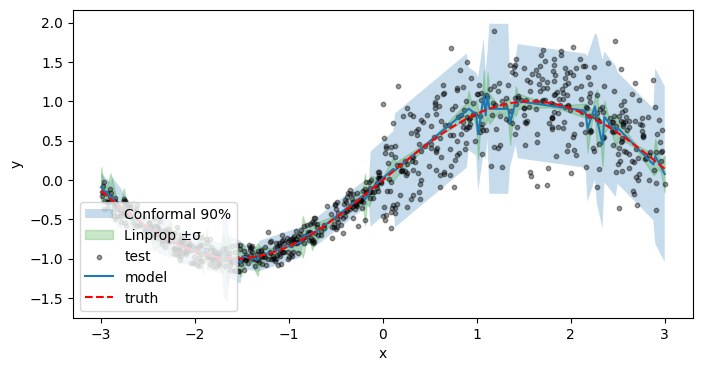

In [5]:
xs = np.linspace(-3, 3, 300).reshape(-1, 1)
yh = np.asarray(model.predict(xs))
sigma_xs = np.asarray(LinearPropagationUQ().predict(model.tree_, xs))
lo_xs, hi_xs = calib.predict_interval(xs, model=model)
lo_xs, hi_xs = np.asarray(lo_xs), np.asarray(hi_xs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(xs[:, 0], lo_xs, hi_xs, alpha=0.25, label="Conformal 90%")
ax.fill_between(
    xs[:, 0], yh - sigma_xs, yh + sigma_xs,
    alpha=0.25, color="C2", label="Linprop ±σ",
)
ax.scatter(X_te, y_te, s=10, alpha=0.4, label="test", color="k")
ax.plot(xs[:, 0], yh, color="C0", label="model")
ax.plot(xs[:, 0], np.sin(xs[:, 0]), color="r", linestyle="--", label="truth")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="lower left")
plt.show()


## Reading the plot

* **Conformal 90%** band has *marginal* coverage close to 90% on average over calibration draws — a single small calibration set fluctuates by roughly `±sqrt(alpha*(1-alpha)/N_test)` (≈1.5 percentage points at this size). The band is wider where leaves contain noisier residuals (Mondrian effect).
* **Linprop ±σ** is cheap but is a Gaussian-heuristic approximation; it does *not* guarantee coverage.
* The two together let you triage where the model is confident vs. extrapolating.

If a `UserWarning` mentions sparse leaves, the default `sparse_leaf_strategy="global"` borrows the global residual quantile for those leaves — preserving marginal coverage but losing per-leaf exchangeability there. Use `sparse_leaf_strategy="skip"` if you'd rather get `NaN` intervals than a leaky guarantee on those buckets.
